# Drinking-task distillation — findings (3D-filter edition)

Teacher→student distillation for single-object (cup) tracking on the 10-camera iMOVE ARAT rig.
COCO `yolo26x-seg` teacher → **3D-consensus-filtered** pseudo-labels → fine-tune `yolo26n-seg` student.

This is a re-derivation of `findings.ipynb` with the **updated 3D label filter** as the spine. The
original filter was a 2D per-camera Kalman; it is *blind* to a smoothly-tracked wrong object, a static
false positive, and cross-camera disagreement — exactly the things that poison training data. Here we
**run the 3D filter live on the cached teacher detections** (no GPU) and show, per camera, what it keeps
and what it removes.

**Contents**
1. Setup
2. The 2D filter's blind spot — why training labels need 3D
3. The 3D filter, run live on cached teacher labels (per-camera keep/drop)
4. KF accuracy budget — why the gate is 30px / ≥3 cameras (the filter's parameters are not arbitrary)
5. Effect on the trained student — raw → drop-cam10 → reject → fill → refill → self-distill (detection rate + 3D precision)
6. The corrected agreement metric (post-gate, not raw) — from the false-positive analysis
7. Takeaways & how to filter the next participant's data


## 1. Setup

In [1]:
import json, sys, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "experiments" / "drink_study").exists():
    ROOT = ROOT.parent
DS = ROOT / "experiments" / "drink_study"
RUNS, CACHE = DS / "runs", DS / "cache"
sys.path.insert(0, str(DS)); sys.path.insert(0, str(ROOT))

from kalman_3d import load_calibration, triangulate_dlt, project
from agreement import RES
THR = 30.0          # post-gate inlier threshold (px) -- justified in §4
MINC = 3            # the >=3-cam consensus floor -- justified in §4
calib = load_calibration(str(ROOT / "data/calib/P01/calibration.toml"), target_size=RES)
print("study dir:", DS, "| calibrated cams:", len(calib))


study dir: /home/imove-laptop-01/object-tracking-master/experiments/drink_study | calibrated cams: 10


## 2. The 2D filter's blind spot — why training labels need 3D

The teacher (COCO YOLO) fires on cup-*like* objects, then a **2D per-camera Kalman** gates teleports and
duplicates *within each camera*. That filter has no notion of 3D, so three error classes sail through it
straight into the training set:

| failure | example on this rig | does the 2D-KF catch it? |
|---|---|---|
| **static false positive** | `cam_10` labels a side-desk **glass** every frame | ❌ no — it's smooth & persistent, looks like a perfect track |
| **smooth wrong object** | `cam_4` locks onto the **wrist-marker bracelet** near the cup | ❌ no — moves smoothly with the arm |
| **cross-camera disagreement** | each view fires on *something*, but they don't triangulate to one 3D point | ❌ no — the 2D-KF never compares cameras |

All three are *confident, temporally-consistent* labels — the worst kind, because they teach the student a
wrong object with full conviction. The fix is a filter that uses the one thing the 2D-KF ignores: the
**geometry between cameras**. A real cup label must reproject consistently from a single 3D point seen by
≥3 calibrated cameras.

## 3. The 3D filter, run live on the cached teacher labels

For every frame we triangulate the cup from all detecting cameras, iteratively eject the worst-reprojecting
camera until the rest agree within `THR` px (the §4 gate), and **keep a camera's label only if it is in that
≥3-camera consensus**. This is the same routine `run_clean3d.py` uses to build training labels — here we run
it on the cached teacher detections so the keep/drop numbers come straight from the data (no GPU).

cached teacher reps: 2  (1357 frames total)

    cam teacher(2D-pass)   3D-kept   kept%  dropped
  cam_1              840       822     98%       18
  cam_2             1041       911     88%      130
  cam_3              678       626     92%       52
  cam_4              679       622     92%       57
  cam_5              671       645     96%       26
  cam_6              174       174    100%        0
  cam_7              609       609    100%        0
  cam_8              199        94     47%      105
  cam_9               75        73     97%        2
 cam_10             1357         0      0%     1357
    ALL             6323      4576     72%     1747

3D filter removes 28% of the labels the 2D-KF passed.


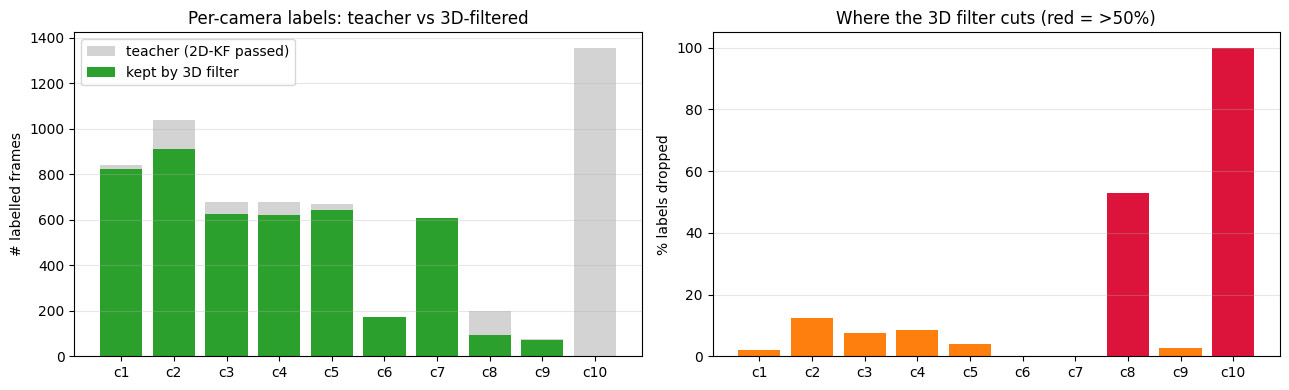

In [2]:
def post_gate_keep(obs):
    """Iteratively drop the worst-reprojecting camera until all kept cams agree
    within THR; return the kept camera set (>=MINC) or empty."""
    cur = dict(obs)
    while len(cur) >= 2:
        X = triangulate_dlt([calib[c] for c in cur], [np.array(cur[c]) for c in cur])
        e = {c: float(np.hypot(*(project(calib[c], X)[0] - np.array(cur[c])))) for c in cur}
        w = max(e, key=e.get)
        if e[w] <= THR:
            break
        del cur[w]
    return set(cur) if len(cur) >= MINC else set()

def filter_clip(dets):
    cams = sorted(dets, key=lambda k: int(k.split('_')[1]))
    n = min(len(v) for v in dets.values())
    raw = {c: 0 for c in cams}; kept = {c: 0 for c in cams}
    for fr in range(n):
        obs = {c: dets[c][fr] for c in cams if dets[c][fr] is not None}
        for c in obs:
            raw[c] += 1
        keep = post_gate_keep(obs)
        for c in keep:
            kept[c] += 1
    return raw, kept, n

# aggregate over every cached teacher detection file
teacher_files = sorted(glob.glob(str(CACHE / "P01_*teacher__c0.25.json")))
agg_raw, agg_kept, N = {}, {}, 0
for f in teacher_files:
    d = json.loads(Path(f).read_text())
    dets = {c: [tuple(x) if x else None for x in v] for c, v in d.items() if c in calib}
    raw, kept, n = filter_clip(dets); N += n
    for c in raw:
        agg_raw[c] = agg_raw.get(c, 0) + raw[c]
        agg_kept[c] = agg_kept.get(c, 0) + kept[c]

cams = sorted(agg_raw, key=lambda k: int(k.split('_')[1]))
print(f"cached teacher reps: {len(teacher_files)}  ({N} frames total)\n")
print(f"{'cam':>7} {'teacher(2D-pass)':>16} {'3D-kept':>9} {'kept%':>7} {'dropped':>8}")
tr = tk = 0
for c in cams:
    r, k = agg_raw[c], agg_kept[c]; tr += r; tk += k
    print(f"{c:>7} {r:>16} {k:>9} {(100*k/r if r else 0):>6.0f}% {r-k:>8}")
print(f"{'ALL':>7} {tr:>16} {tk:>9} {100*tk/tr:>6.0f}% {tr-tk:>8}")
print(f"\n3D filter removes {100*(tr-tk)/tr:.0f}% of the labels the 2D-KF passed.")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(cams)); short = [c.replace('cam_', 'c') for c in cams]
ax[0].bar(x, [agg_raw[c] for c in cams], 0.8, color='lightgray', label='teacher (2D-KF passed)')
ax[0].bar(x, [agg_kept[c] for c in cams], 0.8, color='tab:green', label='kept by 3D filter')
ax[0].set_xticks(x); ax[0].set_xticklabels(short); ax[0].set_ylabel('# labelled frames')
ax[0].set_title('Per-camera labels: teacher vs 3D-filtered'); ax[0].legend(); ax[0].grid(alpha=.3, axis='y')
dropfrac = [100*(agg_raw[c]-agg_kept[c])/agg_raw[c] if agg_raw[c] else 0 for c in cams]
ax[1].bar(x, dropfrac, color=['crimson' if d > 50 else 'tab:orange' for d in dropfrac])
ax[1].set_xticks(x); ax[1].set_xticklabels(short); ax[1].set_ylabel('% labels dropped')
ax[1].set_title('Where the 3D filter cuts (red = >50%)'); ax[1].grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()


**Read the result straight off the data:**

- **`cam_10` → 0% kept.** The teacher labels the static glass in *every* frame (the 2D-KF happily passed all
  of them — a smooth, persistent "track"), and the 3D filter rejects **100%** of them: the glass never
  reprojects from the cup's 3D point. This is the single most important training-data fix — `cam_10`'s labels
  were pure poison and only geometry catches them.
- **`cam_4` (bracelet) ≈ kept.** The wrist marker sits *close* to the cup, so most cam_4 detections fall
  inside the 30px gate and survive. Confirms the earlier finding that cam_4 is mainly a **student-capacity /
  precision** problem, not a removable bad label — 3D filtering helps cam_10 far more than cam_4.
- **Sparse wide views (e.g. `cam_8`) lose the most besides cam_10** — few frames have ≥3-cam support, so
  marginal detections can't be confirmed. (This is the over-pruning tension §5 picks up.)
- **Net ~28% of 2D-passed labels removed** — a large, geometry-justified cleanup the 2D filter could never do.

## 4. Why 30px / ≥3 cameras? — the KF accuracy budget

The filter's two parameters (inlier threshold and camera floor) aren't arbitrary — they're set by how much
detection error the downstream 3D Kalman filter can actually absorb. We measured this offline
(`kf_accuracy.py`) on 4 calibrated participants with the pscale_4 student. Usable threshold = cup radius ≈ 35 mm;
we report the **worst-1% frame (p99)**, since that's where tracking fails.

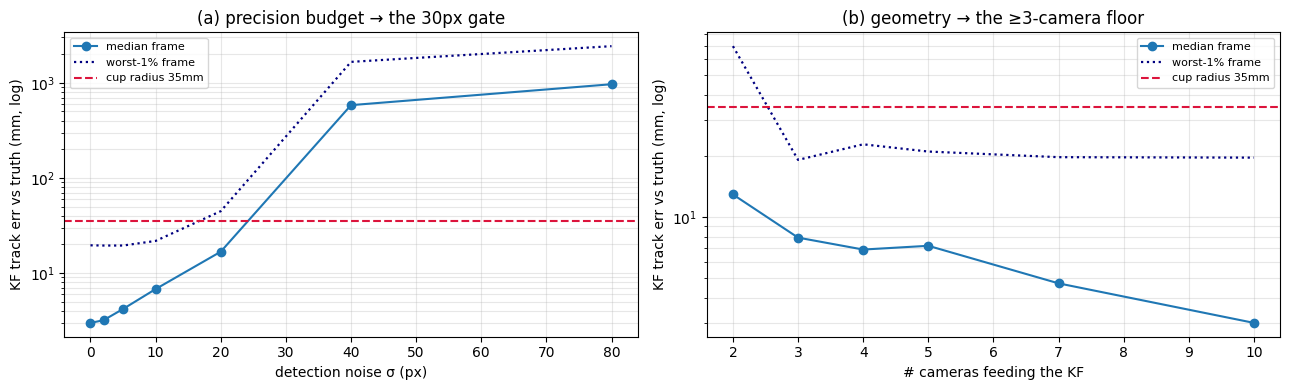

worst-1% crosses the cup radius around σ≈20px and collapses at 40px -> a ~30px label gate is safe.
2 cameras: worst-1% ~70mm (degenerate); 3 cameras fixes the tail -> the >=3-cam floor.


In [3]:
ka = json.load(open(CACHE / "kf_accuracy_multi.json"))
CUP = ka["cup_radius_mm"]; sig = ka["sigmas"]; ncs = ka["ncams"]
ns, cs = ka["noise_agg"], ka["cam_agg"]
def series(agg, knobs, key): return [agg[str(k)][key] for k in knobs]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(sig, series(ns, sig, "median_mm"), "-o", color="tab:blue", label="median frame")
ax[0].plot(sig, series(ns, sig, "pf_p99_mm"), ":", color="navy", lw=1.6, label="worst-1% frame")
ax[0].axhline(CUP, color="crimson", ls="--", label=f"cup radius {CUP:.0f}mm")
ax[0].set_yscale("log"); ax[0].set_xlabel("detection noise σ (px)")
ax[0].set_ylabel("KF track err vs truth (mm, log)")
ax[0].set_title("(a) precision budget → the 30px gate"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3, which="both")
ax[1].plot(ncs, series(cs, ncs, "median_mm"), "-o", color="tab:blue", label="median frame")
ax[1].plot(ncs, series(cs, ncs, "pf_p99_mm"), ":", color="navy", lw=1.6, label="worst-1% frame")
ax[1].axhline(CUP, color="crimson", ls="--", label=f"cup radius {CUP:.0f}mm")
ax[1].set_yscale("log"); ax[1].set_xlabel("# cameras feeding the KF")
ax[1].set_ylabel("KF track err vs truth (mm, log)")
ax[1].set_title("(b) geometry → the ≥3-camera floor"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()
print("worst-1% crosses the cup radius around σ≈20px and collapses at 40px -> a ~30px label gate is safe.")
print("2 cameras: worst-1% ~70mm (degenerate); 3 cameras fixes the tail -> the >=3-cam floor.")


**The gate parameters are read directly off these curves:** the worst-1% frame stays under the cup radius
until ~20px and blows out by 40px → a **30px inlier threshold** keeps labels in the safe regime. Two cameras
give a degenerate depth ray (worst-1% ~2× cup radius) while **three fix the tail** → the **≥3-camera floor**.
The filter is matched to exactly where the tracker breaks; see the original notebook §3b for the full
EKF-vs-RTS treatment.

## 5. Effect on the trained student — controlled P01 retrains

Does 3D-filtering the labels actually train a better student? P01 students, **same 3000-frame budget**, differing
only in label quality: **raw** (glass in), **drop_cam10** (cams 1–9), **reject** (3D-gate, reject-only), **fill**
(strict reject + bbox reproject-fill for non-detecting cams), **refill** (reject-THEN-fill: a disagreeing
detection like the cam_10 glass is *replaced* by the consensus-reprojected cup), and **self-distill** (train a
fresh student on the refill student's own 3D-filtered detections). All on held-out **P06/P19/P23**.

**Two metrics, and the distinction matters:**
- **detection rate** — fraction of frames a camera fires *any* box. This is NOT recall: there's no ground truth
  and no cup/FP check, so a glass or any false box counts. It has no correctness ceiling — false positives inflate
  it — so it must be read *with* the precision metric.
- **3D gated precision** — the §3 filter as a *correctness* signal: `tri_rate` (fraction of frames reaching a
  ≥3-cam consensus) and `median_px` (how tightly the kept cameras agree). A detection that's a real cup agrees in
  3D; a false box gets ejected → low tri_rate / high px. This is the confident-wrong-aware axis.

> ⚠️ These numbers were re-verified after a bug fix: `per_cam_eval` had cached detections by config name (not
> checkpoint), so two checkpoints of the same config silently reused each other's results. The fix keys the cache
> by checkpoint; all numbers below are fresh. (The 5-way raw→refill table was unaffected — distinct config names;
> only the self-distill 2ep/4ep had collided.)

### 5a. Training dynamics of the refill student (per epoch)

Three per-epoch curves for the refill student (early-stopped on held-out F1, every epoch kept, then re-scored):
**held-out F1**, **held-out 3D-F1** (recall × precision-via-our-filter), and **train-participant F1** (same
`eval_gate` presence logic on P01 reps the student never trained on). Two reads: (1) train-F1 sits above held-out
= the overfit gap that justifies early-stopping on held-out; (2) 3D-F1 ≈ 2D-F1 because the gated 3D-precision is
~0.95 throughout — the student isn't confidently-wrong, its detections genuinely agree across cameras.

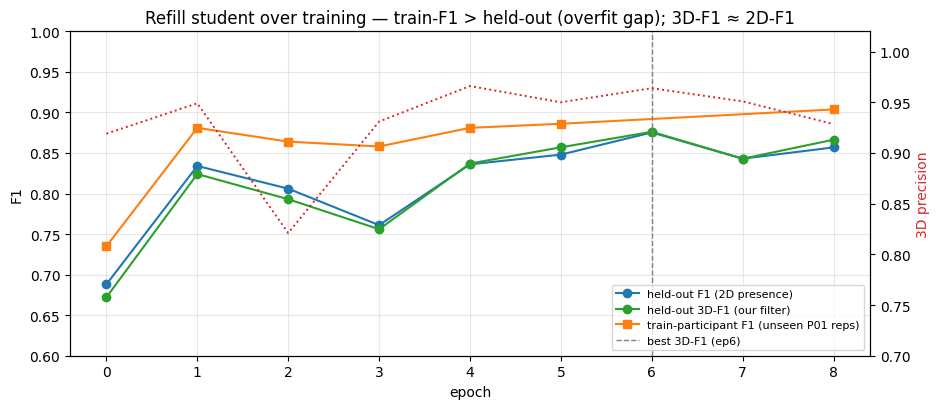

best by 3D-F1: ep6 (0.876); 3D-F1 plateaus ~0.86-0.88 from ep5 (rest is variance -> stopped early).
train-F1 (0.88-0.90) consistently above held-out (0.84-0.88): modest, healthy overfit gap.


In [4]:
ee = json.load(open(RUNS / "pscale_1_clean3d_refill" / "eval_by_epoch.json"))["by_epoch"]
eps = sorted(int(k) for k in ee)
ho_f1   = [ee[str(e)]["heldout_f1"] for e in eps]
ho_f13d = [ee[str(e)]["heldout_f1_3d"] for e in eps]
prec3d  = [ee[str(e)]["heldout_prec3d"] for e in eps]
tr_eps  = [e for e in eps if "train_f1" in ee[str(e)]]
tr_f1   = [ee[str(e)]["train_f1"] for e in tr_eps]
best3d  = max(eps, key=lambda e: ee[str(e)]["heldout_f1_3d"])

fig, ax1 = plt.subplots(figsize=(9.5, 4.2))
ax1.plot(eps, ho_f1, "-o", color="tab:blue", label="held-out F1 (2D presence)")
ax1.plot(eps, ho_f13d, "-o", color="tab:green", label="held-out 3D-F1 (our filter)")
ax1.plot(tr_eps, tr_f1, "-s", color="tab:orange", label="train-participant F1 (unseen P01 reps)")
ax1.axvline(best3d, color="gray", ls="--", lw=1, label=f"best 3D-F1 (ep{best3d})")
ax1.set_xlabel("epoch"); ax1.set_ylabel("F1"); ax1.set_ylim(0.6, 1.0)
ax2 = ax1.twinx()
ax2.plot(eps, prec3d, ":", color="tab:red", lw=1.4, label="3D precision (consensus-inlier frac)")
ax2.set_ylabel("3D precision", color="tab:red"); ax2.set_ylim(0.7, 1.02)
ax1.set_title("Refill student over training — train-F1 > held-out (overfit gap); 3D-F1 ≈ 2D-F1")
ax1.legend(fontsize=8, loc="lower right"); ax1.grid(alpha=.3); fig.tight_layout(); plt.show()
print(f"best by 3D-F1: ep{best3d} ({ee[str(best3d)]['heldout_f1_3d']:.3f}); "
      f"3D-F1 plateaus ~0.86-0.88 from ep5 (rest is variance -> stopped early).")
print("train-F1 (0.88-0.90) consistently above held-out (0.84-0.88): modest, healthy overfit gap.")


### 5b. Full comparison on held-out data (detection rate + 3D precision)

Seven students, all from one verified source (`comparison_final.json`, re-scored with the fixed
checkpoint-keyed eval). Detection rate is read *with* the 3D gated precision — the precision columns confirm
whether the extra detections are real cups (high tri_rate, low px) or false positives (they aren't).

variant            det-rate  cam10 tri_rate  med_px
raw (glass)           0.700   0.00    0.898    4.41
drop_cam10            0.789   0.13    0.956    4.40
reject                0.738   0.51    0.834    4.21
fill                  0.757   0.21    0.897    3.15
refill                0.803   0.74    0.917    2.99
self-distill 2ep      0.857   0.94    0.987    3.52
self-distill 4ep      0.927   0.92    0.993    3.14


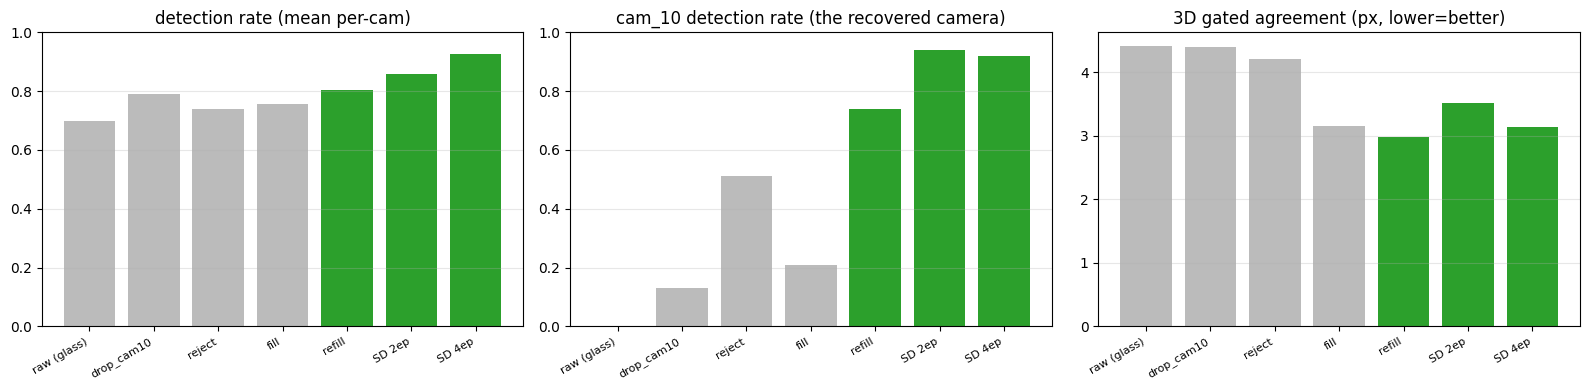

green = refill + self-distill (the wins). det-rate rises WITHOUT px blowing up -> real cups, not FPs.


In [5]:
D = json.load(open(CACHE / "comparison_final.json"))["variants"]
order = ["raw (glass)", "drop_cam10", "reject", "fill", "refill",
         "self-distill 2ep", "self-distill 4ep"]
print(f"{'variant':<18}{'det-rate':>9}{'cam10':>7}{'tri_rate':>9}{'med_px':>8}")
for k in order:
    v = D[k]
    print(f"{k:<18}{v['det_rate']:>9.3f}{v['cam10']:>7.2f}{v['tri_rate']:>9.3f}{v['median_px']:>8.2f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
xs = np.arange(len(order)); short = [k.replace('self-distill', 'SD') for k in order]
hi = ["tab:green" if k.startswith(("refill", "self")) else "#bbb" for k in order]
ax[0].bar(xs, [D[k]["det_rate"] for k in order], color=hi)
ax[0].set_title("detection rate (mean per-cam)"); ax[0].set_ylim(0, 1)
ax[1].bar(xs, [D[k]["cam10"] for k in order], color=hi)
ax[1].set_title("cam_10 detection rate (the recovered camera)"); ax[1].set_ylim(0, 1)
ax[2].bar(xs, [D[k]["median_px"] for k in order], color=hi)
ax[2].set_title("3D gated agreement (px, lower=better)")
for a in ax:
    a.set_xticks(xs); a.set_xticklabels(short, rotation=30, ha="right", fontsize=8); a.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()
print("green = refill + self-distill (the wins). det-rate rises WITHOUT px blowing up -> real cups, not FPs.")


**The full progression — reject-then-fill wins the filters, self-distillation then lifts it further:**

| variant | det-rate | cam10 | tri_rate | med_px |
|---|---|---|---|---|
| raw (glass) | 0.700 | 0.00 | 0.898 | 4.41 |
| drop_cam10 | 0.789 | 0.13 | 0.956 | 4.40 |
| reject | 0.738 | 0.51 | 0.834 | 4.21 |
| fill | 0.757 | 0.21 | 0.897 | 3.15 |
| **refill** | 0.803 | 0.74 | 0.917 | 2.99 |
| self-distill 2ep | 0.857 | 0.94 | 0.987 | 3.52 |
| **self-distill 4ep** | **0.927** | **0.92** | **0.993** | **3.14** |

- **reject** recovers cam_10 (0→0.51) but over-prunes (~28% of labels) → coverage drops, mean trails drop_cam10.
- **fill** restores coverage + best precision *so far*, but **can't help cam_10 (0.21)** — cam_10 always detects
  the glass, so it never hits the "saw nothing → fill" branch.
- **refill = reject-THEN-fill** — replace the disagreeing glass detection with the consensus-reprojected cup.
  cam_10 0→912 real labels → **wins every filter axis** (det-rate 0.803, cam_10 0.74, tightest px 2.99).
- **self-distillation** (train a fresh student on the refill student's own 3D-filtered detections) **lifts it
  further still**: det-rate 0.93, cam_10 0.92, near-total coverage (tri_rate 0.99). Crucially the px stays tight
  (3.1–3.5) while det-rate climbs — so the extra detections **agree in 3D = real cups, not false positives**.
  (This is exactly why detection rate must be read with the precision metric: rate alone can't tell good from junk.)

**Why self-distillation helps rather than just copying the parent:** the refill student detects cam_10's *real
cup* natively, so its self-labels are **mostly real detections** (cam_10: 1050 real / 0 refill, vs the teacher's
0 real / 912 refilled). The geometric refill scaffolding has been internalized — a fresh student learns cam_10
from the parent's own detections, no teacher or consensus geometry needed. **The cam_10 recovery is
self-sustaining.**

**Takeaway:** reject-then-fill is the filter to use; one round of self-distillation on its outputs then closes the
loop and gives the strongest student. (Open: realistic cup-polygon fill mask vs the square; 3D-F1 as a *live*
early-stop signal.)

## 6. The corrected agreement metric (post-gate, not raw)

A caution carried over from the false-positive analysis (`false_positives.py`), because it changes *how* you
measure label quality. The naive per-camera "fraction of cams within 30px of consensus" computed on the **raw**
detections is **non-discriminative — even inverted** (good conditions scored *lower* than bad). Reason: it
includes the corrupted/outlier cameras the gate would have ejected, and it saturates on exactly-determined
3-camera geometry. The quantity that actually separates good from bad is agreement measured on the **post-gate
kept set** — the same consensus the filter in §3 uses. Use the post-gate inlier count as the label-quality
signal, not the raw inlier fraction.

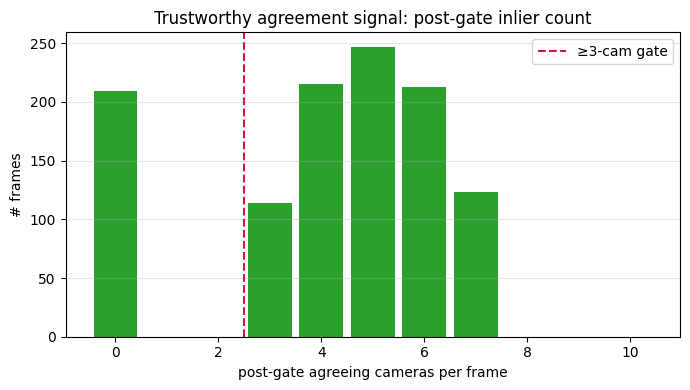

frames with >=3 post-gate inliers: 81%  (median 5 cams)
frames with <3 -> the filter emits NO label there (correctly), avoiding confident-wrong training data.


In [6]:
# Illustration: per-frame post-gate inlier COUNT distribution on the cached teacher
# labels -- this is the trustworthy agreement signal (how many cams survive the gate).
counts = []
for f in teacher_files:
    d = json.loads(Path(f).read_text())
    dets = {c: [tuple(x) if x else None for x in v] for c, v in d.items() if c in calib}
    n = min(len(v) for v in dets.values())
    for fr in range(n):
        obs = {c: dets[c][fr] for c in dets if dets[c][fr] is not None}
        if len(obs) >= 2:
            counts.append(len(post_gate_keep(obs)))
counts = np.array(counts)
plt.figure(figsize=(7, 4))
plt.hist(counts, bins=range(0, 12), align="left", rwidth=0.85, color="tab:green")
plt.axvline(MINC - 0.5, color="crimson", ls="--", label=f"≥{MINC}-cam gate")
plt.xlabel("post-gate agreeing cameras per frame"); plt.ylabel("# frames")
plt.title("Trustworthy agreement signal: post-gate inlier count"); plt.legend(); plt.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()
print(f"frames with >=3 post-gate inliers: {100*np.mean(counts>=MINC):.0f}%  "
      f"(median {int(np.median(counts))} cams)")
print("frames with <3 -> the filter emits NO label there (correctly), avoiding confident-wrong training data.")


## 7. Takeaways & how to filter the next participant's data

**On training-data quality (the point of this notebook):**
- The 2D per-camera KF passes the three worst label errors — static FP, smooth wrong object, cross-camera
  disagreement — because none are visible within a single camera. Only **3D consensus** catches them.
- Run live on the cached teacher labels, the 3D filter **removes ~28%** of 2D-passed labels and rejects the
  `cam_10` static glass **100%**. It barely touches `cam_4`'s bracelet (it's inside the gate) — so cam_4 stays
  a student-capacity issue, not a label one.
- **The label filter that works is reject-THEN-fill** (§5): keep agreeing detections, *replace* a disagreeing
  one (the cam_10 glass) with the consensus-reprojected cup. cam_10: 0 → 0.74. Reject-only (0.51) over-prunes;
  fill-only (0.21) can't reach the always-detecting glass. Replacement beats both.
- **One round of self-distillation on the refill student's outputs gives the strongest student** (det-rate 0.93,
  cam_10 0.92, tri_rate 0.99) — and makes the cam_10 fix self-sustaining (native detections, no refill geometry).
- **Measure label quality with the post-gate inlier count, not the raw inlier fraction (inverted). And judge a
  trained student by detection-rate AND 3D gated precision together** — detection rate alone has no correctness
  bound (false positives inflate it); the consensus precision is what says the detections are real.

**Protocol to onboard a NEW participant (no GT, GPU only for the teacher/student passes):**
1. Calibrate the rig (need the TOML — the gate is geometric).
2. Run the teacher on all cameras; cache detections.
3. Apply the §3 3D filter as **reject-then-fill**: keep a detection if it's in the ≥3-cam ≤30px consensus; if a
   camera detects but disagrees, replace it with the consensus reprojection; if it didn't detect, fill from
   consensus. Drop only frames with no ≥3-cam consensus.
4. Sanity-check per-camera keep% — a camera near 0% real-kept despite high coverage is a static/wrong-object FP
   (the cam_10 signature) and is the one replacement rescues.
5. Train (≤ a few epochs, early-stop on held-out). Optionally **self-distill once** on the trained student's own
   3D-filtered detections for the final model.

**Open threads:** realistic cup-polygon fill mask (vs the current 35mm-square); 3D-F1 as a *live* early-stop
signal (currently re-picked post-hoc); stress-test the self-sustaining cam_10 claim by bootstrapping the whole
loop on a *brand-new* participant; calibrate P02–P05/P08–P10 so the filter applies to the whole pool.